# Task 4: Visualizations and Business Recommendations
## Ethiopian Bank App Review Analysis — Omega Consultancy

This notebook produces stakeholder-ready visualizations and 
concrete recommendations for CBE, BOA, and Dashen Bank based 
on sentiment and theme analysis of 683 Google Play reviews.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("Libraries loaded successfully")

Libraries loaded successfully


In [3]:
try:
    df = pd.read_csv("../data/raw/theme_reviews.csv")
    df['date'] = pd.to_datetime(df['date'])
    print(f"Loaded {len(df)} reviews")
    print(f"Banks: {df['bank'].unique().tolist()}")
    print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
    df.head(3)
except Exception as e:
    print(f"ERROR: {e}")

Loaded 683 reviews
Banks: ['CBE', 'BOA', 'Dashen']
Date range: 2023-04-28 to 2026-05-15


## 1. Sentiment Distribution by Bank
This chart compares positive, neutral, and negative reviews across all three banks.
BOA has the highest proportion of negative reviews indicating urgent product issues.

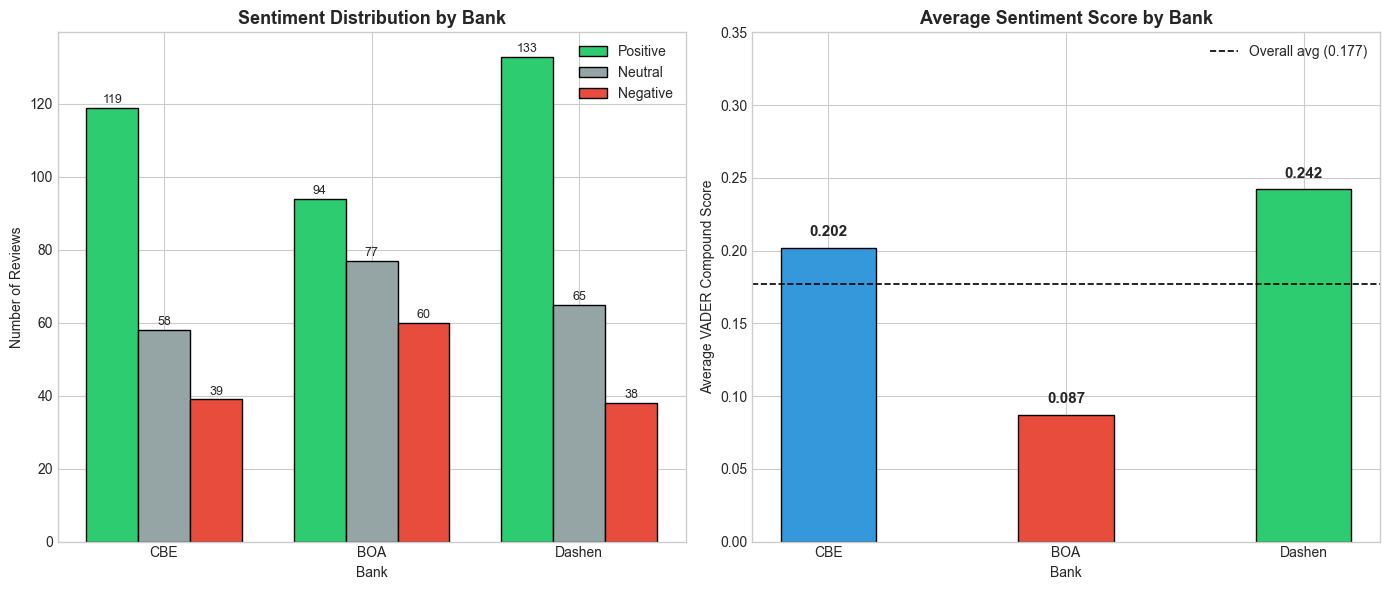

Chart 1 saved


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1 - Grouped bar chart
banks = ['CBE', 'BOA', 'Dashen']
positive = [df[df['bank']==b]['sentiment_label'].eq('positive').sum() for b in banks]
neutral = [df[df['bank']==b]['sentiment_label'].eq('neutral').sum() for b in banks]
negative = [df[df['bank']==b]['sentiment_label'].eq('negative').sum() for b in banks]

x = np.arange(len(banks))
width = 0.25

bars1 = axes[0].bar(x - width, positive, width, label='Positive', color='#2ecc71', edgecolor='black')
bars2 = axes[0].bar(x, neutral, width, label='Neutral', color='#95a5a6', edgecolor='black')
bars3 = axes[0].bar(x + width, negative, width, label='Negative', color='#e74c3c', edgecolor='black')

axes[0].set_title('Sentiment Distribution by Bank', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Bank')
axes[0].set_ylabel('Number of Reviews')
axes[0].set_xticks(x)
axes[0].set_xticklabels(banks)
axes[0].legend()

for bar in bars1 + bars2 + bars3:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                str(int(bar.get_height())), ha='center', va='bottom', fontsize=9)

# Chart 2 - Average sentiment score
avg_scores = df.groupby('bank')['sentiment_score'].mean().reindex(banks)
colors = ['#3498db', '#e74c3c', '#2ecc71']
bars = axes[1].bar(banks, avg_scores.values, color=colors, edgecolor='black', width=0.4)
axes[1].set_title('Average Sentiment Score by Bank', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Bank')
axes[1].set_ylabel('Average VADER Compound Score')
axes[1].set_ylim(0, 0.35)
axes[1].axhline(avg_scores.mean(), color='black', linestyle='--', linewidth=1.2, label=f'Overall avg ({avg_scores.mean():.3f})')
axes[1].legend()

for bar, score in zip(bars, avg_scores.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                f'{score:.3f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/chart1_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved")

## 2. Theme Analysis by Bank
App Performance is the most common complaint theme across all banks.
BOA leads in performance issues while Dashen users focus more on UI design.

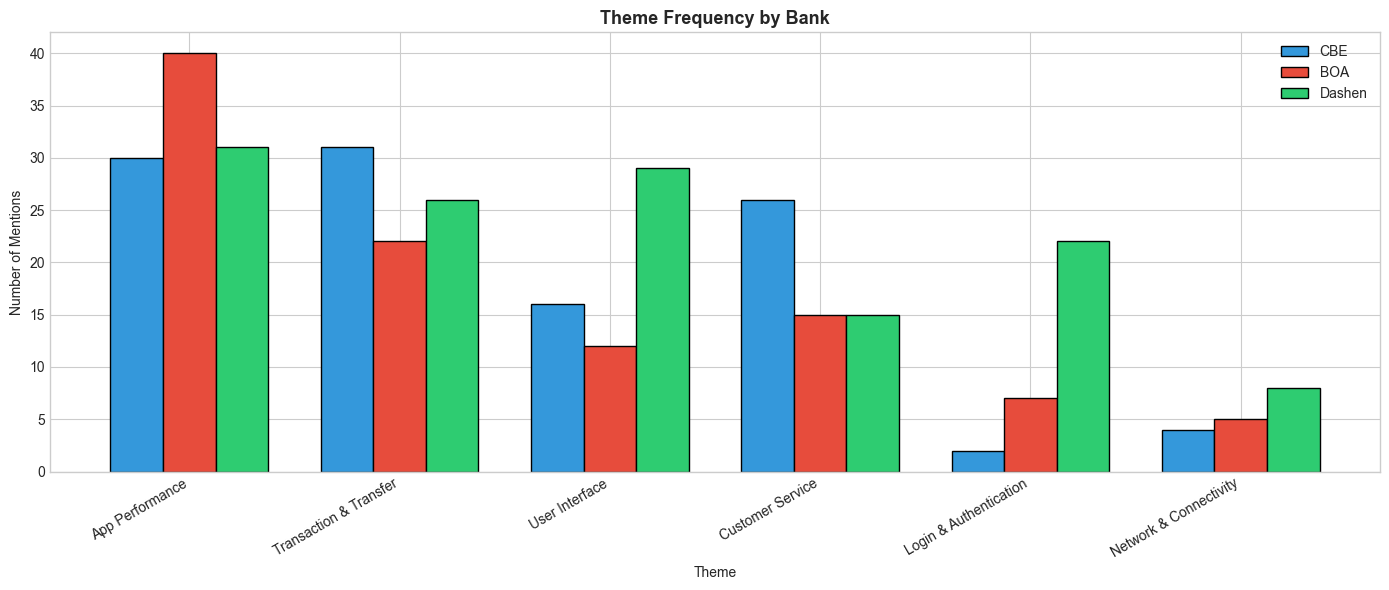

Chart 2 saved


In [7]:
from collections import Counter

# Build theme counts per bank
theme_data = {}
for bank in ['CBE', 'BOA', 'Dashen']:
    bank_themes = []
    for themes in df[df['bank'] == bank]['themes']:
        bank_themes.extend([t.strip() for t in str(themes).split(',')])
    counts = Counter(bank_themes)
    counts.pop('General', None)
    theme_data[bank] = counts

themes_list = ['App Performance', 'Transaction & Transfer',
               'User Interface', 'Customer Service',
               'Login & Authentication', 'Network & Connectivity']

cbe_counts = [theme_data['CBE'].get(t, 0) for t in themes_list]
boa_counts = [theme_data['BOA'].get(t, 0) for t in themes_list]
dashen_counts = [theme_data['Dashen'].get(t, 0) for t in themes_list]

x = np.arange(len(themes_list))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width, cbe_counts, width, label='CBE', color='#3498db', edgecolor='black')
ax.bar(x, boa_counts, width, label='BOA', color='#e74c3c', edgecolor='black')
ax.bar(x + width, dashen_counts, width, label='Dashen', color='#2ecc71', edgecolor='black')

ax.set_title('Theme Frequency by Bank', fontsize=13, fontweight='bold')
ax.set_xlabel('Theme')
ax.set_ylabel('Number of Mentions')
ax.set_xticks(x)
ax.set_xticklabels(themes_list, rotation=30, ha='right')
ax.legend()

plt.tight_layout()
plt.savefig('../data/chart2_themes.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved")

## 3. Rating Distribution by Bank
CBE and Dashen show strong 5-star ratings while BOA has significantly 
more 1-star reviews indicating serious user dissatisfaction.

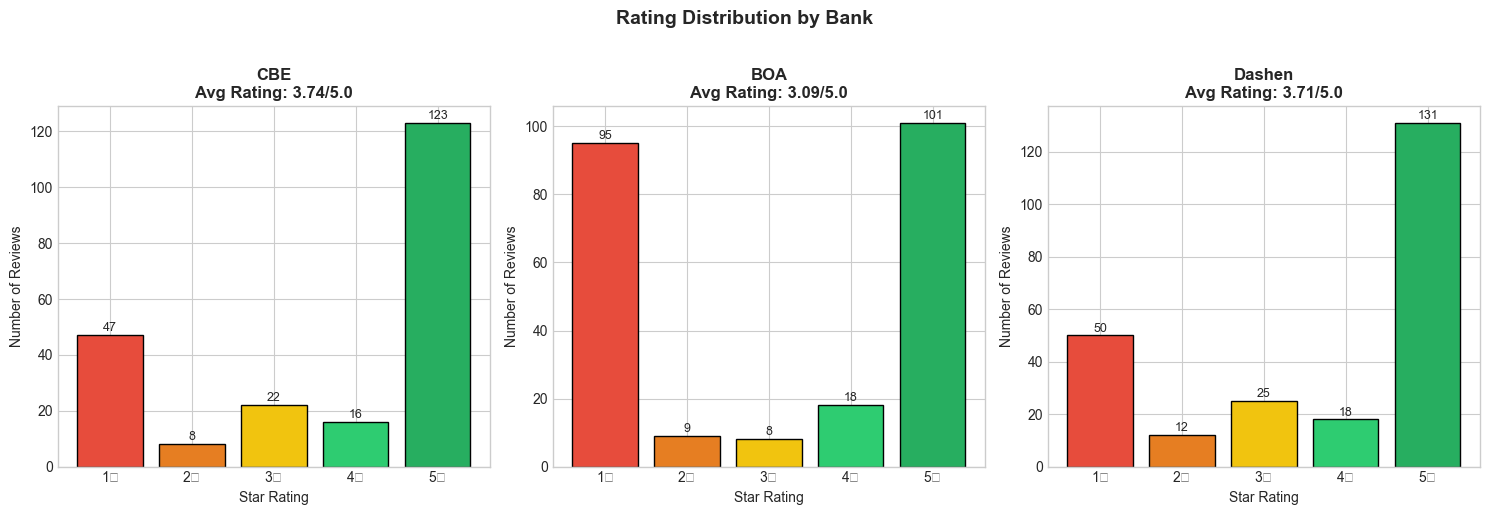

Chart 3 saved


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, bank in enumerate(['CBE', 'BOA', 'Dashen']):
    bank_df = df[df['bank'] == bank]
    rating_counts = bank_df['rating'].value_counts().sort_index()
    
    colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']
    bars = axes[i].bar(rating_counts.index, rating_counts.values,
                       color=colors[:len(rating_counts)], edgecolor='black')
    
    avg = bank_df['rating'].mean()
    axes[i].set_title(f'{bank}\nAvg Rating: {avg:.2f}/5.0', 
                      fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Star Rating')
    axes[i].set_ylabel('Number of Reviews')
    axes[i].set_xticks([1, 2, 3, 4, 5])
    axes[i].set_xticklabels(['1★', '2★', '3★', '4★', '5★'])
    
    for bar in bars:
        axes[i].text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.3,
                    str(int(bar.get_height())),
                    ha='center', va='bottom', fontsize=9)

plt.suptitle('Rating Distribution by Bank', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/chart3_ratings.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved")

## 4. Sentiment Trend Over Time
Tracking how user sentiment changes over time reveals whether 
app updates are improving or worsening the user experience.

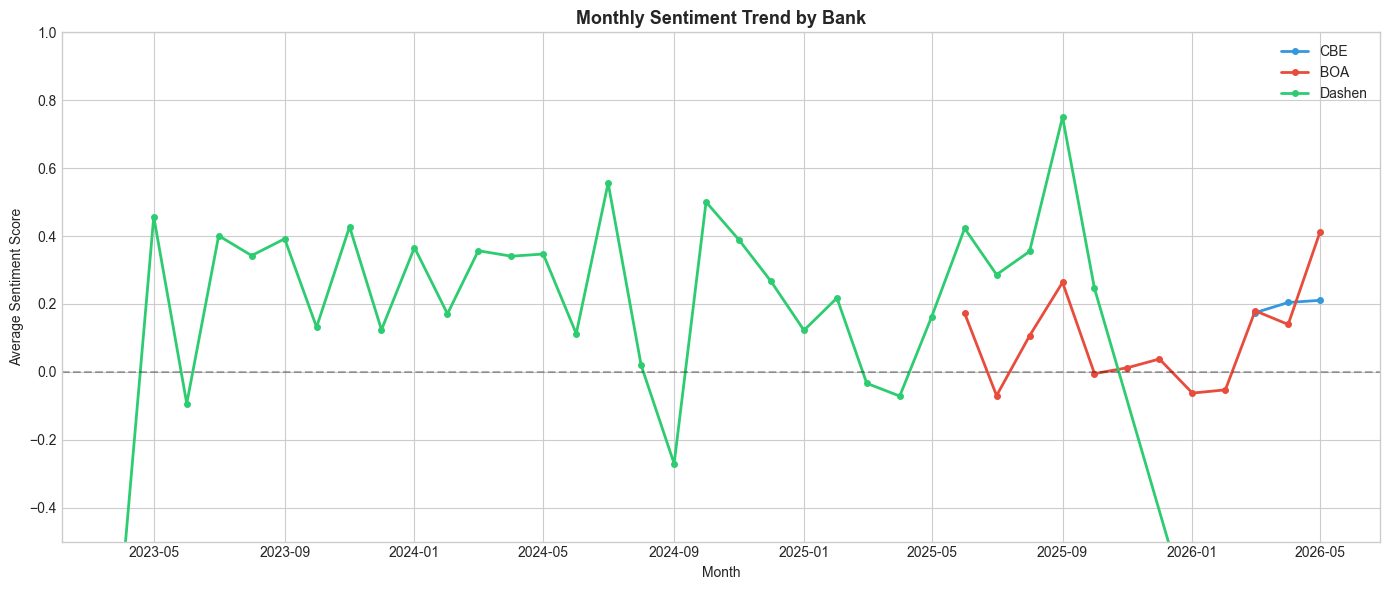

Chart 4 saved


In [9]:
fig, ax = plt.subplots(figsize=(14, 6))

colors = {'CBE': '#3498db', 'BOA': '#e74c3c', 'Dashen': '#2ecc71'}

for bank in ['CBE', 'BOA', 'Dashen']:
    bank_df = df[df['bank'] == bank].copy()
    bank_df['month_year'] = bank_df['date'].dt.to_period('M')
    monthly = bank_df.groupby('month_year')['sentiment_score'].mean()
    monthly.index = monthly.index.to_timestamp()
    
    ax.plot(monthly.index, monthly.values, 
            label=bank, color=colors[bank], 
            linewidth=2, marker='o', markersize=4)

ax.set_title('Monthly Sentiment Trend by Bank', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Average Sentiment Score')
ax.axhline(0, color='black', linestyle='--', alpha=0.3)
ax.legend()
ax.set_ylim(-0.5, 1.0)

plt.tight_layout()
plt.savefig('../data/chart4_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved")

## 5. Business Recommendations
Concrete product recommendations for each bank based on the data analysis.

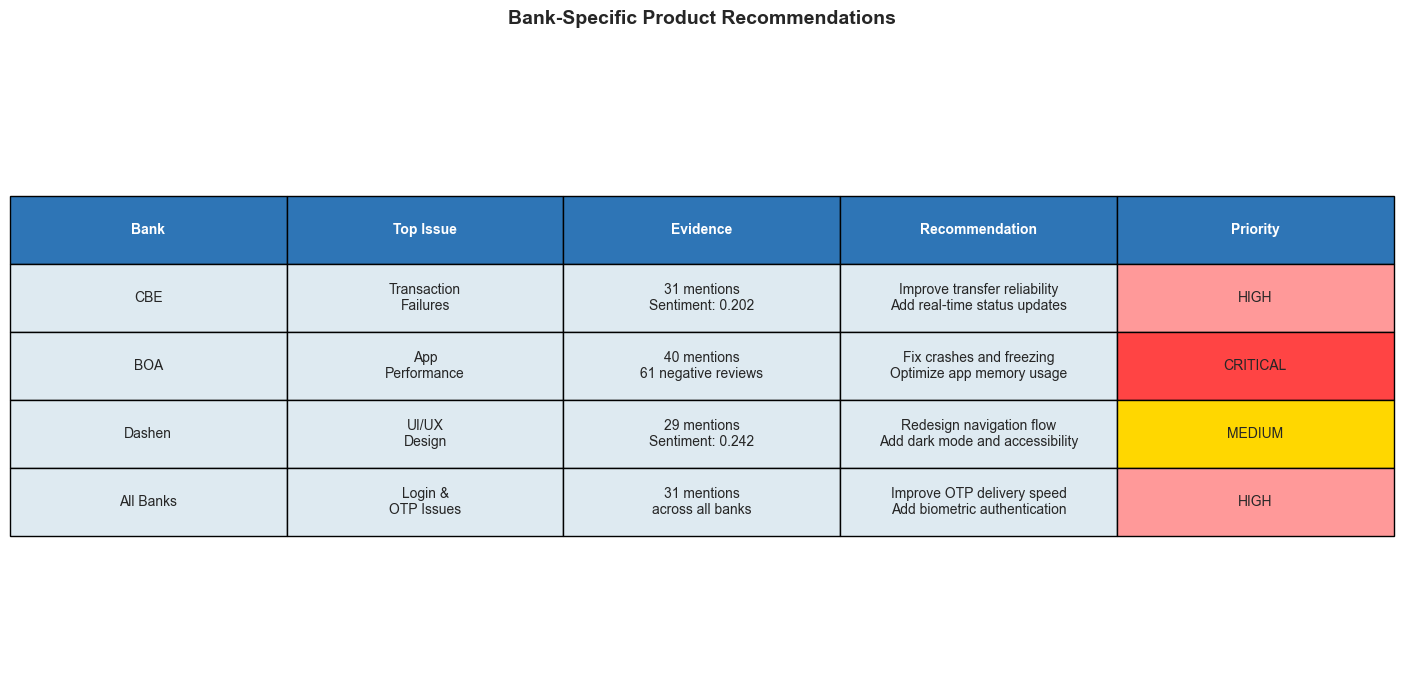

Chart 5 saved


In [10]:
fig, ax = plt.subplots(figsize=(14, 7))
ax.axis('off')

recommendations = [
    ["Bank", "Top Issue", "Evidence", "Recommendation", "Priority"],
    ["CBE", "Transaction\nFailures", "31 mentions\nSentiment: 0.202", 
     "Improve transfer reliability\nAdd real-time status updates", "HIGH"],
    ["BOA", "App\nPerformance", "40 mentions\n61 negative reviews",
     "Fix crashes and freezing\nOptimize app memory usage", "CRITICAL"],
    ["Dashen", "UI/UX\nDesign", "29 mentions\nSentiment: 0.242",
     "Redesign navigation flow\nAdd dark mode and accessibility", "MEDIUM"],
    ["All Banks", "Login &\nOTP Issues", "31 mentions\nacross all banks",
     "Improve OTP delivery speed\nAdd biometric authentication", "HIGH"],
]

colors_table = [
    ['#2E75B6'] * 5,
    ['#DEEAF1'] * 4 + ['#FF9999'],
    ['#DEEAF1'] * 4 + ['#FF4444'],
    ['#DEEAF1'] * 4 + ['#FFD700'],
    ['#DEEAF1'] * 4 + ['#FF9999'],
]

table = ax.table(
    cellText=recommendations[1:],
    colLabels=recommendations[0],
    cellLoc='center',
    loc='center',
    cellColours=colors_table[1:]
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 3.5)

for j in range(5):
    table[0, j].set_facecolor('#2E75B6')
    table[0, j].set_text_props(color='white', fontweight='bold')

ax.set_title('Bank-Specific Product Recommendations', 
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('../data/chart5_recommendations.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 5 saved")

## 6. Key Insights Summary

In [11]:
print("=" * 55)
print("OMEGA CONSULTANCY — FINAL INSIGHTS SUMMARY")
print("=" * 55)

for bank in ['CBE', 'BOA', 'Dashen']:
    bank_df = df[df['bank'] == bank]
    avg_score = bank_df['sentiment_score'].mean()
    avg_rating = bank_df['rating'].mean()
    neg_pct = (bank_df['sentiment_label'] == 'negative').mean() * 100
    pos_pct = (bank_df['sentiment_label'] == 'positive').mean() * 100

    bank_themes = []
    for themes in bank_df['themes']:
        bank_themes.extend([t.strip() for t in str(themes).split(',')])
    theme_counts = Counter(bank_themes)
    theme_counts.pop('General', None)
    top_theme = theme_counts.most_common(1)[0][0] if theme_counts else 'N/A'

    print(f"\n{bank}:")
    print(f"  Average Rating:     {avg_rating:.2f}/5.0")
    print(f"  Sentiment Score:    {avg_score:.3f}")
    print(f"  Positive Reviews:   {pos_pct:.1f}%")
    print(f"  Negative Reviews:   {neg_pct:.1f}%")
    print(f"  Top Issue:          {top_theme}")

print("\n" + "=" * 55)
print("OVERALL RANKING (by sentiment score):")
ranking = df.groupby('bank')['sentiment_score'].mean().sort_values(ascending=False)
for i, (bank, score) in enumerate(ranking.items(), 1):
    print(f"  {i}. {bank}: {score:.3f}")
print("=" * 55)

OMEGA CONSULTANCY — FINAL INSIGHTS SUMMARY

CBE:
  Average Rating:     3.74/5.0
  Sentiment Score:    0.202
  Positive Reviews:   55.1%
  Negative Reviews:   18.1%
  Top Issue:          Transaction & Transfer

BOA:
  Average Rating:     3.09/5.0
  Sentiment Score:    0.087
  Positive Reviews:   40.7%
  Negative Reviews:   26.0%
  Top Issue:          App Performance

Dashen:
  Average Rating:     3.71/5.0
  Sentiment Score:    0.242
  Positive Reviews:   56.4%
  Negative Reviews:   16.1%
  Top Issue:          App Performance

OVERALL RANKING (by sentiment score):
  1. Dashen: 0.242
  2. CBE: 0.202
  3. BOA: 0.087
